# Module 09 Lab - Ensemble Methods**Objective:** To learn how to use **ensemble methods**, which combine the predictions of several individual models to produce a final prediction that is more accurate and robust than any of the individual models alone.**In this lab, you will train and compare a single Decision Tree against a powerful ensemble method, the Random Forest.**

## Part 1: The Wisdom of the Crowd**Concept:** The core idea behind ensemble methods is the "wisdom of the crowd." If you ask one person a difficult question, they might be wrong. But if you ask a large, diverse group of people the same question and average their answers, the result is often surprisingly accurate.Ensemble methods apply this to machine learning. Instead of relying on a single model, we build a "committee" of models and have them vote on the final prediction.Two popular ensemble techniques:*   **Bagging (Bootstrap Aggregating):** Trains multiple models (e.g., Decision Trees) on different random subsets of the training data. The **Random Forest** is the most famous example.*   **Boosting:** Trains models sequentially, where each new model focuses on correcting the errors made by the previous one. Examples include Gradient Boosting and AdaBoost.

## Part 2: SetupWe will use the Iris dataset to classify flower species.

In [2]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load and prepare data
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Part 3: A Single Decision TreeA single Decision Tree is prone to overfitting. It can create very specific rules that match the training data perfectly but don't generalize well.**Your Task:** Train a single `DecisionTreeClassifier` and evaluate its accuracy.

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create the model
tree = DecisionTreeClassifier(random_state=42)

# Train the model
tree.fit(X_train, y_train)

# Make predictions
y_pred = tree.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 1.0


## Part 4: The Random Forest Ensemble**Concept:** A Random Forest is an ensemble of many Decision Trees. It builds hundreds of trees, each trained on a random subset of the data and using a random subset of the features. To make a prediction, it gets a vote from every tree in the "forest" and chooses the class that gets the most votes.This process of averaging the votes of many diverse trees makes the Random Forest much more robust and less prone to overfitting than a single tree.**Your Task:** Train a `RandomForestClassifier` and compare its accuracy to the single tree.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create the model
forest = RandomForestClassifier(random_state=42)

# Train the model
forest.fit(X_train, y_train)

# Make predictions
y_pred_forest = forest.predict(X_test)

# Evaluate accuracy
forest_accuracy = accuracy_score(y_test, y_pred_forest)

print("Decision Tree Accuracy:", accuracy)
print("Random Forest Accuracy:", forest_accuracy)

Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


## Part 5: Feature Importance**Concept:** A great benefit of tree-based ensembles like Random Forest is that they can tell you which features were most important for making accurate predictions.**Your Task:** Extract and plot the feature importances from your trained Random Forest model.

             Feature  Importance
3   petal width (cm)    0.433982
2  petal length (cm)    0.417308
0  sepal length (cm)    0.104105
1   sepal width (cm)    0.044605


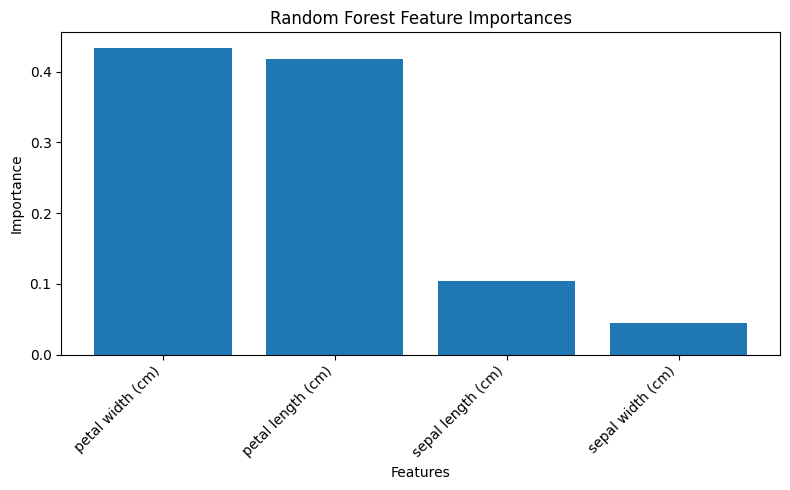

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = forest.feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": iris.feature_names, # Corrected: Use iris.feature_names instead of X.columns
    "Importance": importances
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

# Print the values
print(feature_importance)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **In your own words, what is the main idea behind ensemble methods? Why is a "committee" of models often better than a single expert model?**2.  **Which model performed better in this lab, the single Decision Tree or the Random Forest? Is this what you expected? Why?**3.  **Looking at the feature importance plot, which two features were most important for classifying the iris flowers?** Does this match what you might expect from your own knowledge of flowers?

1. The idea behind ensemble methods is to combine the predictions of different models to make the final prediction better. A committee of models is usually better because it reduces mistakes.

2. The Random Forest performed better than the single Decision Tree. Yes i think this is what I expected because Random Forest combines predictions of many trees, making it more accurate.

3. I think two most important features were petal length and petal width. It makes sense because different iris flower are known to have different sized petals, which makes it useful for classification.